In [1]:

import csv
import logging
import sys
import time

from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import typer

from torch.amp import GradScaler, autocast
from torch.optim import Adam
from torch.utils.data import DataLoader as TorchDataLoader, random_split
from torch_geometric.loader import DataLoader, DataLoader as PyGDataLoader
from tqdm import tqdm

from qqe.experiments.plotting import plot_training_curves
from qqe.GNN.physics_aware_NN import GNN, QuantumCircuitGraphDataset, Regressor

# from qqe.GNN.training.datasets import build_loaders, build_loaders_NN
from qqe.GNN.training.train_config import TrainConfig
from qqe.GNN.training.utils import (
    FamilyFeatureProjector,
    ProjectedDatasetWrapper,
    cache_root_paths,
    collect_files_path,
    evaluate_loss,
    unpack_supervised_batch,
)
from qqe.utils import configure_logger

logger = logging.getLogger(__name__)

In [2]:
class GlobalMLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int = 64, dropout_rate: float = 0.0):
        super().__init__()
        dr = float(dropout_rate) if dropout_rate is not None else 0.0
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, g: torch.Tensor) -> torch.Tensor:
        return self.net(g)

In [3]:
class PaddedGraphDatasetWrapper:
    def __init__(self, dataset, target_dim: int | None = None):
        self.dataset = dataset
        self.target_dim = target_dim or self._compute_max_dim()

    def _compute_max_dim(self) -> int:
        max_dim = 0
        for i in range(len(self.dataset)):
            data = self.dataset[i]
            if hasattr(data, "x") and data.x.dim() > 1:
                max_dim = max(max_dim, data.x.shape[1])
        return max_dim

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, idx: int):
        data = self.dataset[idx]

        if hasattr(data, "x") and data.x.shape[1] < self.target_dim:
            # Pad the feature matrix with zeros
            out = data.clone()
            pad_size = self.target_dim - data.x.shape[1]
            out.x = F.pad(out.x, (0, pad_size), value=0)
            return out
        return data


class GlobalTargetDatasetWrapper:
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        data = self.dataset[idx]

        g = getattr(data, "global_features", None)
        if g is None:
            raise ValueError("Sample is missing 'global_features'.")
        if not torch.is_tensor(g):
            g = torch.as_tensor(g, dtype=torch.float32)
        g = g.flatten().to(torch.float32)

        y = getattr(data, "y", None)
        if y is None:
            y_tensor = torch.tensor(float("nan"), dtype=torch.float32)
        elif torch.is_tensor(y):
            y_tensor = y.flatten()[0].to(torch.float32)
        else:
            print("no tensor")
            y_tensor = torch.tensor(float(y), dtype=torch.float32)

        return g, y_tensor

In [4]:
class GlobalTargetDatasetWrapper:
    def __init__(self, dataset, constant_target: float | None = None):
        self.dataset = dataset
        self.constant_target = constant_target

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        data = self.dataset[idx]

        g = getattr(data, "global_features", None)
        if g is None:
            raise ValueError("Sample is missing 'global_features'.")
        if not torch.is_tensor(g):
            g = torch.as_tensor(g, dtype=torch.float32)
        g = g.flatten().to(torch.float32)

        if self.constant_target is not None:
            y_tensor = torch.tensor(self.constant_target, dtype=torch.float32)
        else:
            y = getattr(data, "y", None)
            if y is None:
                y_tensor = torch.tensor(float("nan"), dtype=torch.float32)
            elif torch.is_tensor(y):
                y_tensor = y.flatten()[0].to(torch.float32)
            else:
                y_tensor = torch.tensor(float(y), dtype=torch.float32)

        return g, y_tensor

In [5]:
def build_loaders_NN(
    pt_paths: list[str],
    *,
    batch_size: int = 32,
    seed: int = 42,
    train_split: float = 0.8,
    val_split: float = 0.1,
    global_feature_variant: str = "binned",
    node_feature_variant: str | None = None,
    family_projection: str | None = None,
):
    suffix = (
        f"{global_feature_variant}"
        f"__backend_{node_feature_variant or 'none'}"
        f"_familyproj_{family_projection or 'none'}"
    )
    root = cache_root_paths(pt_paths, suffix=suffix)

    base_dataset = QuantumCircuitGraphDataset(
        root=root,
        pt_paths=pt_paths,
        global_feature_variant=global_feature_variant,
        node_feature_backend_variant=node_feature_variant,
    )

    if len(base_dataset) < 3:
        raise RuntimeError("Dataset too small for train/val/test splitting.")

    working_dataset = base_dataset
    if family_projection is not None:
        projector = FamilyFeatureProjector(
            family=family_projection,
            all_gate_keys=base_dataset.all_gate_keys,
        )
        working_dataset = ProjectedDatasetWrapper(
            working_dataset,
            transform=projector,
        )

    nn_dataset = GlobalTargetDatasetWrapper(working_dataset)
    sample0_g, _ = nn_dataset[0]


    global_in_dim = int(sample0_g.numel())

    generator = torch.Generator().manual_seed(seed)
    primary_train_len = max(1, int(len(nn_dataset) * train_split))
    test_len = max(1, len(nn_dataset) - primary_train_len)

    while primary_train_len + test_len > len(nn_dataset):
        primary_train_len -= 1

    primary_train_dataset, test_ds = random_split(
        nn_dataset,
        [primary_train_len, test_len],
        generator=generator,
    )

    val_len = max(1, int(len(primary_train_dataset) * val_split))
    real_train_len = max(1, len(primary_train_dataset) - val_len)

    train_ds, val_ds = random_split(
        primary_train_dataset,
        [real_train_len, val_len],
        generator=generator,
    )

    pin_mem = torch.cuda.is_available()

    return (
        TorchDataLoader(
            train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=pin_mem
        ),
        TorchDataLoader(
            val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin_mem
        ),
        TorchDataLoader(
            test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin_mem
        ),
        global_in_dim,
        base_dataset,
    )


In [6]:
def _amp_device_type() -> str:
    return "cuda" if torch.cuda.is_available() else "cpu"

def build_loss(loss_type: str, huber_delta: float = 1.0) -> nn.Module:
    loss_type = loss_type.lower()
    if loss_type == "mse":
        return nn.MSELoss()
    if loss_type == "l1":
        return nn.L1Loss()
    if loss_type == "huber":
        return nn.HuberLoss(delta=huber_delta)
    raise ValueError(f"Unsupported loss type: {loss_type}")


@dataclass
class TrainHistory:
    train_loss: list[float]
    val_loss: list[float]
    lr: list[float]

def _run_train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    scaler: GradScaler,
    device: torch.device,
    *,
    use_amp: bool = True,
    grad_clip: float | None = 5.0,
    epoch_idx: int = 1,
    num_epochs: int = 1,
    show_progress: bool = True,
    log_every_n_batches: int = 20,
    heartbeat_secs: float = 60.0,
) -> tuple[float, float]:
    model.train()
    amp_device = _amp_device_type()

    total_loss = 0.0
    total_graphs = 0
    batch_count = 0

    start_time = time.time()
    last_heartbeat = start_time

    train_iter = tqdm(
        loader,
        desc=f"Epoch {epoch_idx}/{num_epochs}",
        leave=False,
        disable=not show_progress,
        file=sys.stdout,
    )

    for batch in train_iter:
        model_input, y, batch_size = unpack_supervised_batch(batch, device)

        optimizer.zero_grad(set_to_none=True)

        with autocast(
            device_type=amp_device,
            enabled=(use_amp and device.type == "cuda"),
        ):
            pred = model(model_input).view(-1).float()
            mask = torch.isfinite(y)
            if mask.sum() == 0:
                continue
            loss = loss_fn(pred[mask], y[mask])

        if not torch.isfinite(loss):
            logger.warning("Skipping batch with non-finite loss.")
            continue

        scaler.scale(loss).backward()

        if grad_clip is not None and grad_clip > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float(grad_clip))

        scaler.step(optimizer)
        scaler.update()

        total_loss += float(loss.item()) * batch_size
        total_graphs += batch_size
        batch_count += 1

        running_loss = total_loss / max(1, total_graphs)

        if show_progress:
            train_iter.set_postfix(
                {
                    "loss": f"{running_loss:.4f}",
                    "graphs": total_graphs,
                },
            )

        if log_every_n_batches > 0 and batch_count % log_every_n_batches == 0:
            elapsed = time.time() - start_time
            batches_per_sec = batch_count / max(elapsed, 1e-3)
            remaining_batches = len(loader) - batch_count
            eta_secs = remaining_batches / max(batches_per_sec, 1e-3)

            logger.debug(
                f"Epoch {epoch_idx} batch {batch_count}/{len(loader)} | "
                f"loss {running_loss:.6f} | elapsed {elapsed:.1f}s | "
                f"ETA {eta_secs:.1f}s | {batches_per_sec:.2f} batch/s",
            )

        if heartbeat_secs > 0:
            now = time.time()
            if now - last_heartbeat >= heartbeat_secs:
                elapsed = time.time() - start_time
                print(
                    f"[Heartbeat] Epoch {epoch_idx} batch {batch_count}/{len(loader)} | "
                    f"loss {running_loss:.6f} | elapsed {elapsed:.1f}s | graphs {total_graphs}",
                )
                last_heartbeat = now

    epoch_loss = total_loss / max(1, total_graphs)
    elapsed = time.time() - start_time
    return epoch_loss, elapsed


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    *,
    epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    device: str | None = None,
    loss_type: str = "huber",   # "mse" | "huber" | "l1"
    huber_delta: float = 1.0,
    grad_clip: float | None = 5.0,
    early_stopping_patience: int = 15,
    early_stopping_min_delta: float = 0.0,
    use_amp: bool = True,
    scheduler: str = "none",    # "none" | "plateau"
    show_progress: bool = True,
    show_val_progress: bool = False,
    log_every_n_batches: int = 20,
    heartbeat_secs: float = 60.0,
    epoch_time_warning_secs: float = 300.0,
) -> tuple[nn.Module, TrainHistory, torch.device]:
    dev = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    print(f"Using device: {dev}")
    model = model.to(dev)

    loss_fn = build_loss(loss_type=loss_type, huber_delta=huber_delta)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    if scheduler == "plateau":
        lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=5,
        )
    elif scheduler == "none":
        lr_scheduler = None
    else:
        raise ValueError("scheduler must be 'none' or 'plateau'")

    scaler = GradScaler(
        device=_amp_device_type(),
        enabled=(use_amp and dev.type == "cuda"),
    )

    history = TrainHistory(train_loss=[], val_loss=[], lr=[])

    best_val_loss = float("inf")
    best_state_dict = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        epoch_start_time = time.time()
        print(f"-------- EPOCH {epoch:03d} --------")

        train_loss, train_time = _run_train_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            scaler=scaler,
            device=dev,
            use_amp=use_amp,
            grad_clip=grad_clip,
            epoch_idx=epoch,
            num_epochs=epochs,
            show_progress=show_progress,
            log_every_n_batches=log_every_n_batches,
            heartbeat_secs=heartbeat_secs,
        )

        print(f"Training complete ({train_time:.1f}s) | running validation...")

        val_start_time = time.time()
        val_loss = evaluate_loss(
            model=model,
            loader=val_loader,
            device=dev,
            loss_fn=loss_fn,
            use_amp=use_amp,
            show_progress=show_val_progress,
        )
        val_time = time.time() - val_start_time

        if lr_scheduler is not None:
            lr_scheduler.step(val_loss)

        current_lr = float(optimizer.param_groups[0]["lr"])
        history.train_loss.append(float(train_loss))
        history.val_loss.append(float(val_loss))
        history.lr.append(current_lr)

        epoch_time = time.time() - epoch_start_time

        print(
            f"Losses | train {train_loss:.6f} | val {val_loss:.6f} | "
            f"lr {current_lr:.2e} | time train={train_time:.1f}s "
            f"val={val_time:.1f}s total={epoch_time:.1f}s",
        )

        if epoch_time_warning_secs > 0 and epoch_time > epoch_time_warning_secs:
            logger.warning(
                f"Epoch {epoch} took {epoch_time:.1f}s "
                f"(>{epoch_time_warning_secs:.0f}s threshold).",
            )

        improved = val_loss + early_stopping_min_delta < best_val_loss
        if improved:
            best_val_loss = val_loss
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
            logger.debug(f"New best validation loss: {best_val_loss:.6f}")
        else:
            bad_epochs += 1
            logger.debug(
                f"No improvement: patience {bad_epochs}/{early_stopping_patience}",
            )
            if bad_epochs >= early_stopping_patience:
                print(
                    f"Early stopping at epoch {epoch:03d} | "
                    f"best val {best_val_loss:.6f} | "
                    f"patience exhausted ({bad_epochs}/{early_stopping_patience})",
                )
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, history, dev

In [7]:
def run_training_NN(
    cfg: TrainConfig,
    model_type: str | None = None,
    model_params: dict | None = None,
):
    family_filter = cfg.family if cfg.training_mode == "per_family" else None
    family_projection = cfg.family if cfg.training_mode == "per_family" else None

    VALID_FAMILIES = {"haar", "clifford", "quansistor", "random"}
    if cfg.training_mode == "per_family" and cfg.family not in VALID_FAMILIES:
        raise ValueError(
            f"Invalid family: {cfg.family}. Must be one of {sorted(VALID_FAMILIES)}",
        )
    if cfg.training_mode not in {"global", "per_family"}:
        raise ValueError("training_mode must be 'global' or 'per_family'")
    if cfg.training_mode == "per_family" and cfg.family is None:
        raise ValueError("family must be provided when training_mode='per_family'")

    data_paths = collect_files_path("../outputs/data", family=family_filter)
    if not data_paths:
        raise RuntimeError("No data paths found.")

    train_loader, val_loader, test_loader, global_in_dim, base_dataset = build_loaders_NN(
        data_paths,
        batch_size=cfg.batch_size,
        seed=cfg.seed,
        train_split=cfg.train_split,
        val_split=cfg.val_split,
        global_feature_variant=cfg.global_feature_variant,
        node_feature_variant=cfg.node_feature_backend_variant,
        family_projection=family_projection,
    )
    if model_type == "nn":
        pass
    elif model_type == "MLP":
        model = GlobalMLP(
            in_dim = global_in_dim,
            hidden_dim = model_params.get("hidden_dim", 128) if model_params else 64,
            dropout_rate = model_params.get("dropout_rate", 0.0) if model_params else 0.0,
        )
    elif model_type == "regressor":
        model = Regressor(
            in_dim = global_in_dim,
            hidden_dim = model_params.get("hidden_dim", 128) if model_params else 64,
            dropout_rate = model_params.get("dropout_rate", 0.0) if model_params else 0.0,
        )
    else:
        raise ValueError(f"Unsupported model type: {model_type}")

    model, hist, dev = train_model(
        model,
        train_loader,
        val_loader,
        epochs=cfg.epochs,
        lr=cfg.lr,
        loss_type=cfg.loss_type,
        scheduler="plateau",
        show_progress=cfg.show_progress,
        show_val_progress=cfg.show_val_progress,
        log_every_n_batches=cfg.log_batch_loss_every,
        heartbeat_secs=cfg.heartbeat,
        epoch_time_warning_secs=cfg.epoch_warning,
    )

    loss_fn = build_loss(cfg.loss_type, huber_delta=1.0)
    test_loss = evaluate_loss(
        model,
        test_loader,
        dev,
        loss_fn,
        use_amp=True,
        show_progress=True,
    )

    return model, hist, test_loss, global_in_dim, base_dataset

In [8]:
epochs: int = 40
lr: float = 0.001
loss_type: str = "mse"  # "mse" | "huber" | "l1"
training_mode: str = "global"  # "global" | "per_family"
model_type: str = "nn"  # "gnn" | "nn"
allow_overwrite: bool = False
family: str | None = None #"haar"
target: str = "sre"  # "sre" | "ee"
show_progress: bool = True
show_val_progress: bool = False
log_every_n_batches: int = 5
heartbeat_secs: float = 60.0
epoch_time_warning_secs: float = 300.0

cfg = TrainConfig(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    training_mode=training_mode,
    family=family,
    target=target,
    show_progress=show_progress,
    show_val_progress=show_val_progress,
    log_batch_loss_every=log_every_n_batches,
    heartbeat=heartbeat_secs,
    epoch_warning=epoch_time_warning_secs,
)

In [9]:
family_filter = cfg.family if cfg.training_mode == "per_family" else None
family_projection = cfg.family if cfg.training_mode == "per_family" else None

VALID_FAMILIES = {"haar", "clifford", "quansistor", "random"}
if cfg.training_mode == "per_family" and cfg.family not in VALID_FAMILIES:
    raise ValueError(
        f"Invalid family: {cfg.family}. Must be one of {sorted(VALID_FAMILIES)}",
    )
if cfg.training_mode not in {"global", "per_family"}:
    raise ValueError("training_mode must be 'global' or 'per_family'")
if cfg.training_mode == "per_family" and cfg.family is None:
    raise ValueError("family must be provided when training_mode='per_family'")

data_paths = collect_files_path("../outputs/data", family=family_filter)

In [10]:
print(len(data_paths))

27999


In [11]:
def make_datasets(
    cfg: TrainConfig,
    model_type: str | None = None,
    model_params: dict | None = None,
):
    family_filter = cfg.family if cfg.training_mode == "per_family" else None
    family_projection = cfg.family if cfg.training_mode == "per_family" else None

    VALID_FAMILIES = {"haar", "clifford", "quansistor", "random"}
    if cfg.training_mode == "per_family" and cfg.family not in VALID_FAMILIES:
        msg = f"Invalid family: {cfg.family}. Must be one of {sorted(VALID_FAMILIES)}"
        raise ValueError(msg)
    if cfg.training_mode not in {"global", "per_family"}:
        msg_0 = "training_mode must be 'global' or 'per_family'"
        raise ValueError(msg_0)
    if cfg.training_mode == "per_family" and cfg.family is None:
        msg_1 = "family must be provided when training_mode='per_family'"
        raise ValueError(msg_1)

    data_paths = collect_files_path("../outputs/data", family=family_filter)

    train_loader, val_loader, test_loader, global_in_dim, base_dataset = build_loaders_NN(
        data_paths,
        batch_size=cfg.batch_size,
        seed=cfg.seed,
        train_split=cfg.train_split,
        val_split=cfg.val_split,
        global_feature_variant=cfg.global_feature_variant,
        node_feature_variant=cfg.node_feature_backend_variant,
        family_projection=family_projection,
    )

    return train_loader, val_loader, test_loader, global_in_dim, base_dataset

In [12]:
epochs: int = 40
lr: float = 0.001
loss_type: str = "mse"  # "mse" | "huber" | "l1"
training_mode: str = "per_family"  # "global" | "per_family"
model_type: str = "nn"  # "gnn" | "nn"
allow_overwrite: bool = False
family: str | None = "haar"
target: str = "sre"  # "sre" | "ee"
show_progress: bool = True
show_val_progress: bool = False
log_every_n_batches: int = 5
heartbeat_secs: float = 60.0
epoch_time_warning_secs: float = 300.0

train_cfg = TrainConfig(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    training_mode=training_mode,
    family=family,
    target=target,
    show_progress=show_progress,
    show_val_progress=show_val_progress,
    log_batch_loss_every=log_every_n_batches,
    heartbeat=heartbeat_secs,
    epoch_warning=epoch_time_warning_secs,
)

In [13]:
train_loader, val_loader, test_loader, global_in_dim, base_dataset = make_datasets(train_cfg)

In [14]:
xb, yb = next(iter(train_loader))
print(torch.unique(xb))

tensor([1.9585, 2.1663, 2.1822, 2.3400, 2.3456, 2.3559, 2.3664, 3.9122, 4.0168,
        4.0320, 4.0365, 4.0410, 4.0484, 4.0490, 4.0741, 4.0968, 5.5539, 5.7284,
        5.9802, 6.0060, 6.0062, 6.0093, 6.0126, 6.0184, 6.0229, 6.0247, 6.9177,
        8.0039, 8.0051, 8.0077, 8.0130, 8.0132])


In [32]:
print(base_dataset[0].global_features)

tensor([[ 10.,  50., 450.,  39.,  33.,  26.,  35.,  38.,  31.,  40.,  36.,  40.,
          25.,  44.,  31.,  47.,  29.,  28.,  36.,  31.,  26.,  32.,  42.,  38.,
          32.,  26.,  40.,  36.,  40.,  33.,  42.,  31.,  33.,  31.,  40.,  30.,
          33.,  31.,  36.,  41.,  41.,  32.,  41.,  36.,  37.,  37.,  47.,  39.,
          39.,  48.,  45.,  34.,  42.]])


In [15]:
epochs: int = 40
lr: float = 0.001
loss_type: str = "mse"  # "mse" | "huber" | "l1"
training_mode: str = "per_family"  # "global" | "per_family"
model_type: str = "nn"  # "gnn" | "nn"
allow_overwrite: bool = False
family: str | None = "quansistor"
target: str = "sre"  # "sre" | "ee"
show_progress: bool = True
show_val_progress: bool = False
log_every_n_batches: int = 5
heartbeat_secs: float = 60.0
epoch_time_warning_secs: float = 300.0

train_cfg = TrainConfig(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    training_mode=training_mode,
    family=family,
    target=target,
    show_progress=show_progress,
    show_val_progress=show_val_progress,
    log_batch_loss_every=log_every_n_batches,
    heartbeat=heartbeat_secs,
    epoch_warning=epoch_time_warning_secs,
)

train_loader, val_loader, test_loader, global_in_dim, base_dataset = make_datasets(train_cfg)
xb, yb = next(iter(train_loader))
print(torch.unique(yb))

tensor([2.0999, 2.1409, 2.2208, 2.3973, 2.4198, 2.4208, 2.4216, 3.9071, 4.0059,
        4.0138, 4.0873, 4.1096, 4.1102, 4.1143, 4.1184, 4.1280, 4.1327, 6.0051,
        6.0154, 6.0236, 6.0380, 6.0418, 7.0901, 7.4819, 7.9842, 7.9997, 8.0005,
        8.0017, 8.0024, 8.0055, 8.0056, 8.0079])


In [16]:
def _resolve_model_save_path(base_path: str, allow_overwrite: bool = False) -> str:
    """Return a non-colliding checkpoint path unless overwrite is explicitly allowed."""
    path = Path(base_path)
    if allow_overwrite or not path.exists():
        return str(path)

    stem = path.stem
    suffix = path.suffix
    parent = path.parent
    counter = 1

    while True:
        candidate = parent / f"{stem}_v{counter}{suffix}"
        if not candidate.exists():
            print(
                "Model checkpoint already exists at %s. Saving to %s instead.",
                path,
                candidate,
            )
            return str(candidate)
        counter += 1

In [17]:
def run(
    cfg: TrainConfig,
    model_type: str | None = None,
    model_params: dict | None = None,
):
    model, hist, test_loss, global_in_dim, base_dataset = run_training_NN(cfg, model_type=model_type, model_params=model_params)
    node_in_dim = None
    model_hparams = {
        "gnn_hidden": None,
        "gnn_heads": None,
        "global_hidden": None,
        "reg_hidden": None,
        "num_layers": None,
        "dropout_rate": cfg.dropout_rate if hasattr(cfg, "dropout_rate") else 0.0,
    }

    plot_training_curves(
        hist,
        title=f"{model_type.upper()} SRE regression",
        save_fig=True,
        fig_path=f"outputs/figures/training_curves/training_curves_{model_type}_{loss_type}_{family if training_mode == 'per_family' else 'global'}.png",
    )

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "model_config": {
            "node_in_dim": node_in_dim or None,
            "global_in_dim": global_in_dim,
            "gnn_hidden": model_hparams["gnn_hidden"],
            "gnn_heads": model_hparams["gnn_heads"],
            "global_hidden": model_hparams["global_hidden"],
            "reg_hidden": model_hparams["reg_hidden"],
            "num_layers": model_hparams["num_layers"],
            "dropout_rate": model_hparams["dropout_rate"],
        },
        "train_config": asdict(cfg),
        "feature_config": {
            "global_feature_variant": cfg.global_feature_variant,
            "node_feature_backend_variant": cfg.node_feature_backend_variant,
            "all_gate_keys": getattr(base_dataset, "all_gate_keys", None),
            "family_projection": (
                cfg.family if cfg.training_mode == "per_family" else None
            ),
        },
        "final_metrics": {
            "test_loss": float(test_loss),
        },
    }

    # model_save_path = _resolve_model_save_path(
    #         f"../models/{model_type}_model_{loss_type}_{family if training_mode == 'per_family' else 'global'}.pt",
    #         allow_overwrite=allow_overwrite,
    #     )
    model_save_path = f"dummy_model_2.pt"
    torch.save(checkpoint, model_save_path)
    print("Saved model checkpoint to %s", model_save_path)

In [18]:
epochs: int = 10
lr: float = 0.001
loss_type: str = "mse"  # "mse" | "huber" | "l1"
training_mode: str = "global"  # "global" | "per_family"
model_type: str = "nn"  # "gnn" | "nn"
allow_overwrite: bool = False
family: str | None = None #"haar"
target: str = "sre"  # "sre" | "ee"
show_progress: bool = True
show_val_progress: bool = False
log_every_n_batches: int = 5
heartbeat_secs: float = 60.0
epoch_time_warning_secs: float = 300.0

train_config = TrainConfig(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    training_mode=training_mode,
    family=family,
    target=target,
    show_progress=show_progress,
    show_val_progress=show_val_progress,
    log_batch_loss_every=log_every_n_batches,
    heartbeat=heartbeat_secs,
    epoch_warning=epoch_time_warning_secs,
)

Using device: cuda
-------- EPOCH 001 --------
Epoch 1/10:  84%|████████▍ | 3788/4500 [03:00<00:39, 18.19it/s, loss=0.3967, graphs=121248][Heartbeat] Epoch 1 batch 3789/4500 | loss 0.396737 | elapsed 180.1s | graphs 121248
Training complete (220.4s) | running validation...                                         
Losses | train 0.353045 | val 0.130554 | lr 1.00e-03 | time train=220.4s val=27.0s total=247.5s
-------- EPOCH 002 --------
Epoch 2/10:  83%|████████▎ | 3739/4500 [03:00<00:35, 21.69it/s, loss=0.1049, graphs=119680][Heartbeat] Epoch 2 batch 3740/4500 | loss 0.104944 | elapsed 180.1s | graphs 119680
Training complete (217.0s) | running validation...                                         
Losses | train 0.103909 | val 0.089175 | lr 1.00e-03 | time train=217.0s val=21.0s total=238.0s
-------- EPOCH 003 --------
Epoch 3/10:  82%|████████▏ | 3688/4500 [03:00<00:43, 18.84it/s, loss=0.0908, graphs=118048][Heartbeat] Epoch 3 batch 3689/4500 | loss 0.090813 | elapsed 180.1s | graphs 

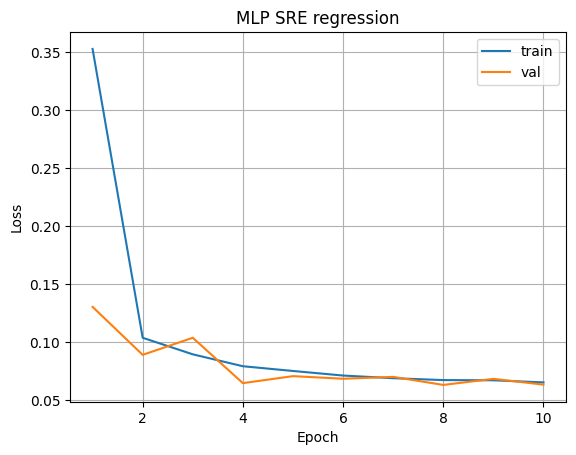

Saved model checkpoint to %s dummy_model_2.pt


In [19]:
# GlobalMLP hidden_dim=128, no dropout, mse loss
run(train_config, model_type="MLP", model_params={"hidden_dim": 128, "dropout_rate": 0.0})

In [20]:
epochs: int = 35
lr: float = 0.001
loss_type: str = "mse"  # "mse" | "huber" | "l1"
training_mode: str = "global"  # "global" | "per_family"
model_type: str = "nn"  # "gnn" | "nn"
allow_overwrite: bool = False
family: str | None = None #"haar"
target: str = "sre"  # "sre" | "ee"
show_progress: bool = True
show_val_progress: bool = False
log_every_n_batches: int = 5
heartbeat_secs: float = 60.0
epoch_time_warning_secs: float = 300.0

train_config = TrainConfig(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    training_mode=training_mode,
    family=family,
    target=target,
    show_progress=show_progress,
    show_val_progress=show_val_progress,
    log_batch_loss_every=log_every_n_batches,
    heartbeat=heartbeat_secs,
    epoch_warning=epoch_time_warning_secs,
)

Using device: cuda
-------- EPOCH 001 --------
Epoch 1/35:  86%|████████▌ | 3871/4500 [03:00<00:29, 21.44it/s, loss=0.3522, graphs=123936][Heartbeat] Epoch 1 batch 3873/4500 | loss 0.352206 | elapsed 180.1s | graphs 123936
Training complete (209.6s) | running validation...                                         
Losses | train 0.318200 | val 0.197270 | lr 1.00e-03 | time train=209.6s val=21.0s total=230.6s
-------- EPOCH 002 --------
Epoch 2/35:  90%|████████▉ | 4048/4500 [03:00<00:18, 24.55it/s, loss=0.0996, graphs=129632][Heartbeat] Epoch 2 batch 4051/4500 | loss 0.099594 | elapsed 180.1s | graphs 129632
Training complete (199.6s) | running validation...                                         
Losses | train 0.099923 | val 0.097493 | lr 1.00e-03 | time train=199.6s val=18.6s total=218.3s
-------- EPOCH 003 --------
Epoch 3/35:  88%|████████▊ | 3969/4500 [03:00<00:25, 21.22it/s, loss=0.0849, graphs=127040][Heartbeat] Epoch 3 batch 3970/4500 | loss 0.084859 | elapsed 180.1s | graphs 

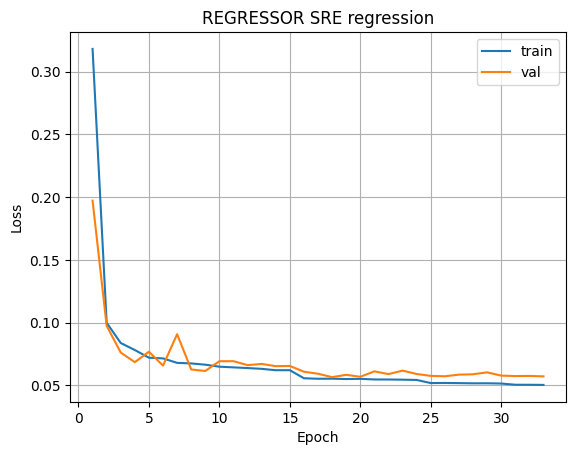

Saved model checkpoint to %s dummy_model_2.pt


In [21]:
# GlobalMLP hidden_dim=128, no dropout, mse loss
run(train_config, model_type="regressor", model_params={"hidden_dim": 128, "dropout_rate": 0.0})

### Prediction

In [22]:
def collect_prediction_paths(dataset_root: str, family: str | None = None) -> list[str]:
    root = Path(dataset_root)
    pred_root = root / "predictions"

    if family is not None:
        paths = sorted((pred_root / family).glob("*.pt"))
    else:
        paths = []
        if pred_root.exists():
            for subdir in sorted(pred_root.iterdir()):
                if subdir.is_dir():
                    paths.extend(sorted(subdir.glob("*.pt")))

    return [str(p.resolve()) for p in paths]


def checkpoint_path(model_kind: str, training_scope: str, family: str | None = None, loss_type: str = "mse") -> Path:
    if model_kind not in {"gnn", "nn"}:
        raise ValueError("model_kind must be 'gnn' or 'nn'")
    if training_scope not in {"global", "family"}:
        raise ValueError("training_scope must be 'global' or 'family'")

    if training_scope == "family":
        if family is None:
            raise ValueError("family must be provided when training_scope='family'")
        return Path(f"models/{model_kind}_model_{loss_type}_{family}.pt")

    return Path(f"models/{model_kind}_model_{loss_type}_global.pt")


def load_checkpoint(path: str | Path) -> tuple[dict[str, Any], dict[str, Any], dict[str, Any]]:
    payload = torch.load(path, map_location="cpu", weights_only=False)

    if not isinstance(payload, dict):
        raise RuntimeError("Checkpoint must be a dict.")

    if "model_state_dict" in payload:
        state_dict = payload["model_state_dict"]
        model_config = payload.get("model_config", {}) or {}
        feature_config = payload.get("feature_config", {}) or {}
    else:
        # older raw state_dict format
        state_dict = payload
        model_config = {}
        feature_config = {}

    return state_dict, model_config, feature_config


def build_model(model_kind: str, model_config: dict[str, Any]) -> torch.nn.Module:
    if model_kind == "gnn":
        return GNN(
            node_in_dim=int(model_config["node_in_dim"]),
            global_in_dim=int(model_config["global_in_dim"]),
            gnn_hidden=int(model_config.get("gnn_hidden", 32)),
            gnn_heads=int(model_config.get("gnn_heads", 8)),
            global_hidden=int(model_config.get("global_hidden", 16)),
            reg_hidden=int(model_config.get("reg_hidden", 16)),
            num_layers=int(model_config.get("num_layers", 5)),
            dropout_rate=float(model_config.get("dropout_rate", 0.1)),
        )

    if model_kind == "nn":
        return Regressor(
            in_dim=int(model_config["global_in_dim"]),
            hidden_dim=int(model_config.get("hidden_dim", 128)),
        )
    
    if model_kind == "MLP":
        return GlobalMLP(
            in_dim = int(model_config["global_in_dim"]),
            hidden_dim = int(model_config.get("hidden_dim", 128)),
            dropout_rate = float(model_config.get("dropout_rate", 0.0)),
        )

    raise ValueError(f"Unsupported model_kind: {model_kind}")

In [23]:
class PredictionGraphWrapper:
    def __init__(
        self,
        dataset,
        target_node_dim: int | None = None,
        target_global_dim: int | None = None,
    ):
        self.dataset = dataset
        self.target_node_dim = target_node_dim
        self.target_global_dim = target_global_dim

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, idx: int):
        data = self.dataset[idx].clone()

        if self.target_node_dim is not None:
            cur = int(data.x.shape[1])
            if cur < self.target_node_dim:
                data.x = F.pad(data.x, (0, self.target_node_dim - cur))
            elif cur > self.target_node_dim:
                data.x = data.x[:, : self.target_node_dim]

        if hasattr(data, "global_features"):
            g = data.global_features
            if g.dim() > 1:
                g = g.view(-1)

            if self.target_global_dim is not None:
                cur = int(g.shape[0])
                if cur < self.target_global_dim:
                    g = F.pad(g, (0, self.target_global_dim - cur))
                elif cur > self.target_global_dim:
                    g = g[: self.target_global_dim]

            data.global_features = g

        return data


class PredictionTensorWrapper:
    def __init__(self, dataset, target_global_dim: int | None = None):
        self.dataset = dataset
        self.target_global_dim = target_global_dim

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, idx: int):
        data = self.dataset[idx]
        g = data.global_features
        if not torch.is_tensor(g):
            g = torch.as_tensor(g, dtype=torch.float32)
        g = g.flatten().to(torch.float32)

        if self.target_global_dim is not None:
            cur = int(g.shape[0])
            if cur < self.target_global_dim:
                g = F.pad(g, (0, self.target_global_dim - cur))
            elif cur > self.target_global_dim:
                g = g[: self.target_global_dim]

        meta = getattr(data, "meta", {}) or {}
        target = extract_target_value(data)
        return g, meta, target


def build_prediction_dataset(
    pt_paths: list[str],
    *,
    global_feature_variant: str,
    node_feature_backend_variant: str | None,
    fixed_all_gate_keys: list[str] | None,
):
    return QuantumCircuitGraphDataset(
        root="qqe/cache/prediction_cache",
        pt_paths=pt_paths,
        global_feature_variant=global_feature_variant,
        node_feature_backend_variant=node_feature_backend_variant,
        fixed_all_gate_keys=fixed_all_gate_keys,
    )


def build_loader(
    model_kind: str,
    dataset,
    *,
    batch_size: int,
    target_node_dim: int | None,
    target_global_dim: int | None,
):
    if model_kind == "gnn":
        wrapped = PredictionGraphWrapper(
            dataset,
            target_node_dim=target_node_dim,
            target_global_dim=target_global_dim,
        )
        return PyGDataLoader(
            wrapped,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )

    if model_kind == "nn" or model_kind == "MLP":
        wrapped = PredictionTensorWrapper(dataset, target_global_dim=target_global_dim)

        def collate_fn(batch):
            xs, metas, targets = zip(*batch)
            return torch.stack(xs, dim=0), list(metas), list(targets)

        return TorchDataLoader(
            wrapped,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
            collate_fn=collate_fn,
        )

    raise ValueError(f"Unsupported model_kind: {model_kind}")

In [24]:
def extract_target_value(sample: Any) -> float | None:
    y = getattr(sample, "y", None)
    if y is None:
        return None

    if torch.is_tensor(y):
        if y.numel() == 0:
            return None
        value = float(y.flatten()[0].item())
    else:
        value = float(y)

    if not np.isfinite(value):
        return None

    return value

@torch.no_grad()
def predict(
    model: torch.nn.Module,
    loader,
    *,
    model_kind: str,
    device: torch.device,
    show_progress: bool = True,
) -> list[dict[str, Any]]:
    model.eval()
    rows: list[dict[str, Any]] = []
    total_batches = len(loader) if hasattr(loader, "__len__") else None

    if model_kind == "gnn":
        for batch in tqdm(
            loader,
            total=total_batches,
            desc="Predicting (gnn)",
            unit="batch",
            disable=not show_progress,
        ):
            samples = batch.to_data_list()
            batch = batch.to(device)
            preds = model(batch).view(-1).cpu().tolist()

            for sample, pred in zip(samples, preds):
                meta = getattr(sample, "meta", {}) or {}
                target = extract_target_value(sample)
                rows.append(
                    {
                        "cid": meta.get("cid"),
                        "family": meta.get("family"),
                        "seed": meta.get("seed"),
                        "n_qubits": meta.get("n_qubits"),
                        "n_layers": meta.get("n_layers"),
                        "target": target,
                        "prediction": float(pred),
                        "error": abs(float(pred - target)) if target is not None else None,
                    },
                )
        return rows

    if model_kind == "nn" or model_kind == "MLP":
        for x, metas, targets in tqdm(
            loader,
            total=total_batches,
            desc="Predicting (nn)",
            unit="batch",
            disable=not show_progress,
        ):
            x = x.to(device)
            preds = model(x).view(-1).cpu().tolist()

            for meta, pred, target in zip(metas, preds, targets):
                rows.append(
                    {
                        "cid": meta.get("cid"),
                        "family": meta.get("family"),
                        "seed": int(meta.get("seed")),
                        "n_qubits": int(meta.get("n_qubits")),
                        "n_layers": int(meta.get("n_layers")),
                        "target": target,
                        "prediction": float(pred),
                        "error": abs(float(pred - target)) if target is not None else None,
                    },
                )
        return rows

    raise ValueError(f"Unsupported model_kind: {model_kind}")

In [25]:
def save_predictions_csv(rows: list[dict[str, Any]], path: str | Path) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    fieldnames = ["cid", "family", "seed", "n_qubits", "n_layers", "target", "prediction", "error"]
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    return path


def aggregate_mean_std(
    rows: list[dict[str, Any]],
    *,
    x_key: str,
    fixed_key: str | None = None,
    fixed_value: int | None = None,
) -> list[dict[str, Any]]:
    filtered = rows
    if fixed_key is not None and fixed_value is not None:
        filtered = [r for r in rows if int(r[fixed_key]) == int(fixed_value)]

    groups: dict[int, list[float]] = {}
    for r in filtered:
        x = int(r[x_key])
        groups.setdefault(x, []).append(float(r["prediction"]))

    out = []
    for x in sorted(groups):
        vals = np.asarray(groups[x], dtype=float)
        out.append(
            {
                x_key: x,
                "mean": float(vals.mean()),
                "std": float(vals.std(ddof=0)),
                "n": len(vals),
            },
        )
    return out

In [26]:
def plot_fixed_layers_vary_qubits(
    rows: list[dict[str, Any]],
    *,
    n_layers: int,
    output_path: str | Path | None = None,
    split_by_family: bool = True,
):
    filtered = [r for r in rows if int(r["n_layers"]) == int(n_layers)]
    if not filtered:
        print("No predictions found for n_layers=%s", n_layers)
        return

    plt.figure(figsize=(8, 5))

    if split_by_family:
        families = sorted({str(r.get("family", "unknown")) for r in filtered})
        for family in families:
            family_rows = [r for r in filtered if str(r.get("family", "unknown")) == family]

            groups: dict[int, list[float]] = {}
            for r in family_rows:
                q = int(r["n_qubits"])
                groups.setdefault(q, []).append(float(r["prediction"]))

            x = sorted(groups.keys())
            y = [np.mean(groups[q]) for q in x]
            yerr = [np.std(groups[q], ddof=0) for q in x]

            plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3, label=family)

        plt.legend(title="family")
        plt.title(f"Predicted SRE vs qubits (n_layers={n_layers})")
    else:
        groups: dict[int, list[float]] = {}
        for r in filtered:
            q = int(r["n_qubits"])
            groups.setdefault(q, []).append(float(r["prediction"]))

        x = sorted(groups.keys())
        y = [np.mean(groups[q]) for q in x]
        yerr = [np.std(groups[q], ddof=0) for q in x]

        plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3)
        plt.title(f"Predicted SRE vs qubits (n_layers={n_layers})")

    plt.xlabel("Number of qubits")
    plt.ylabel("Predicted SRE")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=180)
        plt.close()
    plt.show()

def plot_fixed_qubits_vary_layers(
    rows: list[dict[str, Any]],
    *,
    n_qubits: int,
    output_path: str | Path | None = None,
    split_by_family: bool = True,
):
    filtered = [r for r in rows if int(r["n_qubits"]) == int(n_qubits)]
    if not filtered:
        print("No predictions found for n_qubits=%s", n_qubits)
        return

    plt.figure(figsize=(8, 5))

    if split_by_family:
        families = sorted({str(r.get("family", "unknown")) for r in filtered})
        for family in families:
            family_rows = [r for r in filtered if str(r.get("family", "unknown")) == family]

            groups: dict[int, list[float]] = {}
            for r in family_rows:
                L = int(r["n_layers"])
                groups.setdefault(L, []).append(float(r["prediction"]))

            x = sorted(groups.keys())
            y = [np.mean(groups[L]) for L in x]
            yerr = [np.std(groups[L], ddof=0) for L in x]

            plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3, label=family)

        plt.legend(title="family")
        plt.title(f"Predicted SRE vs layers (n_qubits={n_qubits})")
    else:
        groups: dict[int, list[float]] = {}
        for r in filtered:
            L = int(r["n_layers"])
            groups.setdefault(L, []).append(float(r["prediction"]))

        x = sorted(groups.keys())
        y = [np.mean(groups[L]) for L in x]
        yerr = [np.std(groups[L], ddof=0) for L in x]

        plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3)
        plt.title(f"Predicted SRE vs layers (n_qubits={n_qubits})")

    plt.xlabel("Number of layers")
    plt.ylabel("Predicted SRE")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=180)
        plt.close()
    plt.show()

In [36]:
model_path: str = "dummy_model_2.pt"
model_kind: str = "nn"  # "gnn" | "nn" | "MLP"
training_scope: str = "global"
loss_type: str = "mse"
model_family: str | None = None ###
dataset_root: str = "../outputs/data"
dataset_family: str | None = None ###
batch_size: int = 32
global_feature_variant: str = "binned"
node_feature_backend_variant: str | None = None
plot_n_layers: int = 80
plot_n_qubits: int  = 16
split_by_family: bool = True
show_progress: bool = True

In [37]:
state_dict, model_config, feature_config = load_checkpoint(model_path)

In [38]:
model = build_model(model_kind, model_config)
model.load_state_dict(state_dict, strict=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [39]:
pt_paths = collect_prediction_paths(dataset_root, dataset_family)
if not pt_paths:
    raise RuntimeError("No prediction .pt files found.")

print("Found %d prediction files", len(pt_paths))

RuntimeError: No prediction .pt files found.

In [40]:
dataset = build_prediction_dataset(
    pt_paths,
    global_feature_variant=feature_config.get("global_feature_variant", global_feature_variant),
    node_feature_backend_variant=feature_config.get("node_feature_backend_variant", node_feature_backend_variant),
    fixed_all_gate_keys=feature_config.get("all_gate_keys"),
)

loader = build_loader(
    model_kind,
    dataset,
    batch_size=batch_size,
    target_node_dim=model_config.get("node_in_dim"),
    target_global_dim=model_config.get("global_in_dim"),
)

rows = predict(
    model,
    loader,
    model_kind=model_kind,
    device=device,
    show_progress=show_progress,
)
output_csv = f"../outputs/figures/predictions/{training_scope}/{model_kind}_predictions_{model_family or 'global'}.csv"

save_predictions_csv(rows, output_csv)

Predicting (nn):   0%|          | 0/8438 [00:00<?, ?batch/s]

Predicting (nn): 100%|██████████| 8438/8438 [07:19<00:00, 19.19batch/s]


WindowsPath('../outputs/figures/predictions/global/nn_predictions_global.csv')

In [41]:
rows

[{'cid': 'clifford_Q10_L100_S1008105898',
  'family': 'clifford',
  'seed': 1008105898,
  'n_qubits': 10,
  'n_layers': 100,
  'target': 8.003973960876465,
  'prediction': 7.983325958251953,
  'error': 0.02064800262451172},
 {'cid': 'clifford_Q10_L100_S1017900085',
  'family': 'clifford',
  'seed': 1017900085,
  'n_qubits': 10,
  'n_layers': 100,
  'target': 8.00405216217041,
  'prediction': 7.983160495758057,
  'error': 0.020891666412353516},
 {'cid': 'clifford_Q10_L100_S1032783643',
  'family': 'clifford',
  'seed': 1032783643,
  'n_qubits': 10,
  'n_layers': 100,
  'target': 8.003904342651367,
  'prediction': 7.982954025268555,
  'error': 0.0209503173828125},
 {'cid': 'clifford_Q10_L100_S1034770690',
  'family': 'clifford',
  'seed': 1034770690,
  'n_qubits': 10,
  'n_layers': 100,
  'target': 8.005644798278809,
  'prediction': 7.982091426849365,
  'error': 0.02355337142944336},
 {'cid': 'clifford_Q10_L100_S1054497654',
  'family': 'clifford',
  'seed': 1054497654,
  'n_qubits': 10,

In [42]:
for i in range(5):
    print(f"Sample prediction {i+1}: {rows[i]}")

Sample prediction 1: {'cid': 'clifford_Q10_L100_S1008105898', 'family': 'clifford', 'seed': 1008105898, 'n_qubits': 10, 'n_layers': 100, 'target': 8.003973960876465, 'prediction': 7.983325958251953, 'error': 0.02064800262451172}
Sample prediction 2: {'cid': 'clifford_Q10_L100_S1017900085', 'family': 'clifford', 'seed': 1017900085, 'n_qubits': 10, 'n_layers': 100, 'target': 8.00405216217041, 'prediction': 7.983160495758057, 'error': 0.020891666412353516}
Sample prediction 3: {'cid': 'clifford_Q10_L100_S1032783643', 'family': 'clifford', 'seed': 1032783643, 'n_qubits': 10, 'n_layers': 100, 'target': 8.003904342651367, 'prediction': 7.982954025268555, 'error': 0.0209503173828125}
Sample prediction 4: {'cid': 'clifford_Q10_L100_S1034770690', 'family': 'clifford', 'seed': 1034770690, 'n_qubits': 10, 'n_layers': 100, 'target': 8.005644798278809, 'prediction': 7.982091426849365, 'error': 0.02355337142944336}
Sample prediction 5: {'cid': 'clifford_Q10_L100_S1054497654', 'family': 'clifford', '

### Test

In [50]:
from qqe.experiments.sweeper import (
    JobConfig,
    aggregate_by_cond,
    compile_job,
    generate_jobs,
)
from qqe.circuit.patterns import TdopingRules, to_qasm
from qqe.GNN.encoder import qasm_to_pyg_graph

In [51]:
backend = "pennylane"
target = "SRE"
method = "fwht"
use_dask: bool = True
output_file = "../outputs/data/"
n_bins_option= 50
families: str = "clifford"
n_seeds_option = 1

In [52]:
from qqe.circuit.spec import CircuitSpec, GateSpec

def make_identity_spec(n_qubits: int, n_layers: int, seed: int = 42) -> CircuitSpec:
    gates = []

    for _layer in range(n_layers):
        for q in range(n_qubits):
            gates.append(
                GateSpec(
                    kind="I",      # keep this if your qqe -> QASM path already turns it into id
                    wires=(q,),
                    d=2,
                    params=(),
                )
            )

    return CircuitSpec(
        n_qubits=n_qubits,
        n_layers=n_layers,
        d=2,
        family="clifford",
        connectivity="line",
        pattern="brickwork",
        global_seed=seed,
        gates=gates,
    )

In [68]:
id_circ = make_identity_spec(n_qubits = 16, n_layers=80)

In [69]:
dag = to_qasm(id_circ, id_circ.gates)

In [70]:
print(dag)
data, gate_features = qasm_to_pyg_graph(dag, family="clifford", global_feature_variant="binned")
print(gate_features["I_count"])   # should be 12
print(data.x.shape, data.edge_index.shape)

OPENQASM 2.0;
include "qelib1.inc";
opaque qx(a,b,g) q0,q1;
opaque qy(a,b,g) q0,q1;
opaque haar(s) q0,q1;
qreg q[16];
id q[0];
id q[1];
id q[2];
id q[3];
id q[4];
id q[5];
id q[6];
id q[7];
id q[8];
id q[9];
id q[10];
id q[11];
id q[12];
id q[13];
id q[14];
id q[15];
id q[0];
id q[1];
id q[2];
id q[3];
id q[4];
id q[5];
id q[6];
id q[7];
id q[8];
id q[9];
id q[10];
id q[11];
id q[12];
id q[13];
id q[14];
id q[15];
id q[0];
id q[1];
id q[2];
id q[3];
id q[4];
id q[5];
id q[6];
id q[7];
id q[8];
id q[9];
id q[10];
id q[11];
id q[12];
id q[13];
id q[14];
id q[15];
id q[0];
id q[1];
id q[2];
id q[3];
id q[4];
id q[5];
id q[6];
id q[7];
id q[8];
id q[9];
id q[10];
id q[11];
id q[12];
id q[13];
id q[14];
id q[15];
id q[0];
id q[1];
id q[2];
id q[3];
id q[4];
id q[5];
id q[6];
id q[7];
id q[8];
id q[9];
id q[10];
id q[11];
id q[12];
id q[13];
id q[14];
id q[15];
id q[0];
id q[1];
id q[2];
id q[3];
id q[4];
id q[5];
id q[6];
id q[7];
id q[8];
id q[9];
id q[10];
id q[11];
id q[12];
id q[13];
id

In [71]:
spec = make_identity_spec(n_qubits=4, n_layers=3)
qasm = to_qasm(spec, spec.gates)
print(qasm)
data, gate_features = qasm_to_pyg_graph(qasm, family="clifford", global_feature_variant="binned")
print(gate_features["I_count"])   # should be 12
print(data.x.shape, data.edge_index.shape)

OPENQASM 2.0;
include "qelib1.inc";
opaque qx(a,b,g) q0,q1;
opaque qy(a,b,g) q0,q1;
opaque haar(s) q0,q1;
qreg q[4];
id q[0];
id q[1];
id q[2];
id q[3];
id q[0];
id q[1];
id q[2];
id q[3];
id q[0];
id q[1];
id q[2];
id q[3];

12
torch.Size([20, 67]) torch.Size([2, 16])


In [72]:
from qqe.circuit.DAG import circuit_spec_to_dag
from qqe.GNN.circuit_to_graph import circuit_spec_to_nx_dag

import networkx as nx


In [75]:
dag = circuit_spec_to_nx_dag(id_circ)

In [76]:
pos = {}
layer_node_counts = {}

for node, attrs in dag.nodes(data=True):
    layer = attrs["subset"]
    wires = attrs["wires"]

    # Count nodes at each layer for vertical spacing
    if layer not in layer_node_counts:
        layer_node_counts[layer] = 0

    # Position x by layer, y by qubit(s) involved
    x = layer * 2  # Horizontal spacing by layer
    y = -sum(wires) / len(wires)  # Average qubit index (negative for better layout)

    pos[node] = (x, y)

# Create custom labels based on node attributes
labels = {}
for node, attrs in dag.nodes(data=True):
    kind = attrs["kind"]
    wires = attrs["wires"]
    tags = attrs["tags"]

    # Format wire display
    wire_str = f"q{wires[0]}" if len(wires) == 1 else f"q{wires[0]}-q{wires[1]}"

    # Check for special tag info
    special_tag = None
    if "T-gate" in tags:
        special_tag = "T"
    elif kind == "clifford":
        # First check if decomposition is already in tags
        decomp_tag = None
        for tag in tags:
            if isinstance(tag, str) and tag.startswith("decomp_"):
                decomp_tag = tag.replace("decomp_", "")
                break

        if decomp_tag:
            special_tag = decomp_tag
        else:
            # Fallback: compute from seed
            gate_spec = circuit_spec.gates[node]
            if gate_spec.seed is not None:
                u_a, u_b, _ = clifford_recipe_unitary(gate_spec.seed)
                special_tag = f"{u_a}⊗{u_b}+CX"
            else:
                special_tag = "Cliff"
    elif kind == "quansistor":
        # Extract axis if present
        for tag in tags:
            if isinstance(tag, str) and tag.startswith("axis_"):
                axis = tag.split("_")[1]
                special_tag = f"Q-{axis}"
                break
        if special_tag is None:
            special_tag = "Q"

    # Create concise label
    if special_tag:
        labels[node] = f"{special_tag}\n{wire_str}"
    else:
        labels[node] = f"{kind}\n{wire_str}"

# Color nodes by gate type
gate_colors = {
    "RX": "#FF6B6B",  # Red
    "RY": "#4ECDC4",  # Teal
    "RZ": "#45B7D1",  # Blue
    "H": "#FFA07A",  # Light Salmon
    "S": "#98D8C8",  # Mint
    "T": "#F7DC6F",  # Yellow
    "CNOT": "#BB8FCE",  # Purple
    "clifford": "#D2B4DE",  # Lavender
    "quansistor_X": "#A9DFBF",  # Light Green for X-axis
    "quansistor_Y": "#F8B88B",  # Light Orange for Y-axis
    "quansistor": "#D5D8DC",  # Gray (fallback)
    "haar": "#FAD7A0",  # Peach
}

# Assign colors based on gate type and axis
node_colors = []
for node in dag.nodes():
    kind = dag.nodes[node]["kind"]
    tags = dag.nodes[node]["tags"]

    if kind == "quansistor":
        # Extract axis from tags
        axis = None
        for tag in tags:
            if isinstance(tag, str) and tag.startswith("axis_"):
                axis = tag.split("_")[1]
                break

        if axis:
            node_colors.append(
                gate_colors.get(f"quansistor_{axis}", gate_colors["quansistor"]),
            )
        else:
            node_colors.append(gate_colors["quansistor"])
    else:
        node_colors.append(gate_colors.get(kind, "#D3D3D3"))

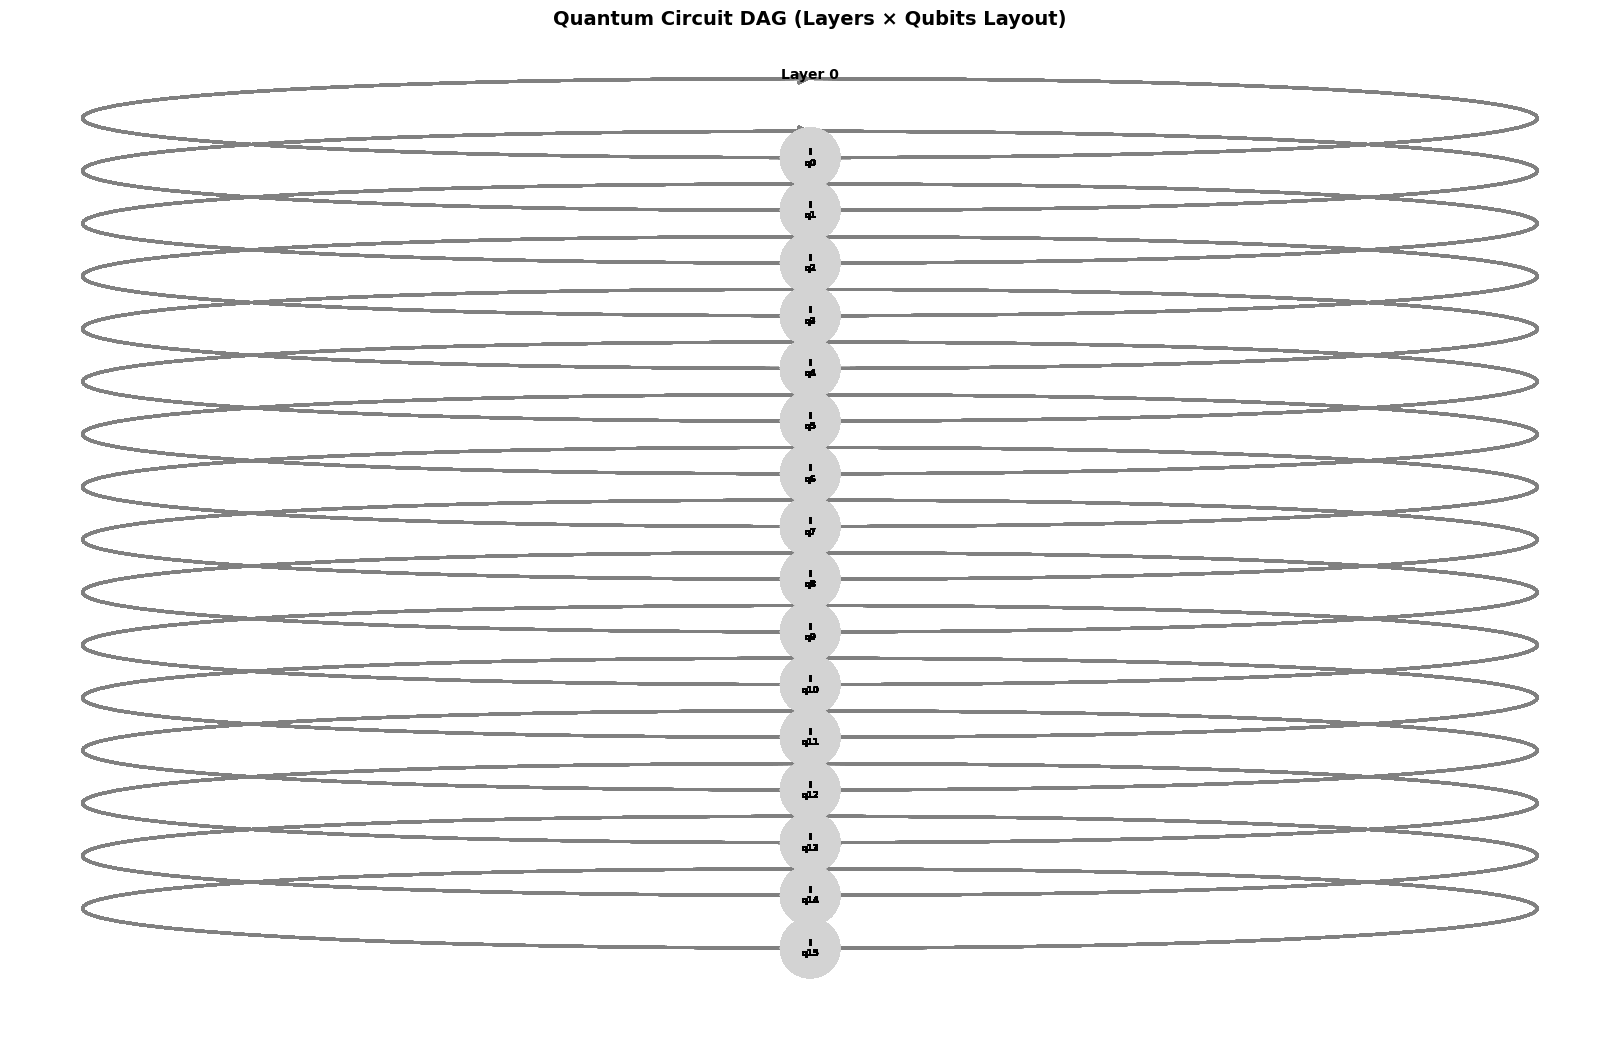

In [77]:
plt.figure(figsize=(16, 10))
nx.draw(
    dag,
    pos=pos,
    labels=labels,
    with_labels=True,
    node_size=1800,
    node_color=node_colors,
    arrowsize=15,
    arrowstyle="->",
    edge_color="gray",
    width=2,
    font_size=6,
    font_color="black",
    font_weight="bold",
)
layer_positions = {}
for layer in layer_node_counts:
    layer_positions[layer] = layer * 2

ax = plt.gca()
for layer, x in layer_positions.items():
    ax.text(
        x,
        max([p[1] for p in pos.values()]) + 1.5,
        f"Layer {layer}",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

plt.title("Quantum Circuit DAG (Layers × Qubits Layout)", fontsize=14, fontweight="bold")
# plt.tight_layout()
# plt.savefig(f"circuit_outputs/DAG_{circuit.name}.png", dpi=150, bbox_inches="tight")
plt.show()


In [83]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict


def visualize_qasm_graph_layered(qasm_str: str, data, figsize=(16, 6)):
    """
    Visualize the PyG circuit graph in a circuit-like layered layout.

    Assumes the graph was built by qasm_to_pyg_graph():
      - input nodes first
      - then one node per parsed op
      - then measurement nodes
    """
    ops = _parse_ops(qasm_str)  # uses your existing parser
    num_qubits = int(data.num_qubits)
    edge_index = data.edge_index.cpu()

    # Build NetworkX DiGraph
    G = nx.DiGraph()
    n_nodes = data.x.shape[0]
    for i in range(n_nodes):
        G.add_node(i)
    for src, dst in edge_index.t().tolist():
        G.add_edge(src, dst)

    # ------------------------------------------------------------------
    # Step 1: assign node labels and node types
    # ------------------------------------------------------------------
    labels = {}
    node_kind = {}

    # Input nodes: 0 .. num_qubits-1
    for q in range(num_qubits):
        node_id = q
        labels[node_id] = f"in[{q}]"
        node_kind[node_id] = "input"

    # Gate nodes: num_qubits .. num_qubits + len(ops)-1
    gate_offset = num_qubits
    for k, (name, params, w0, w1) in enumerate(ops):
        node_id = gate_offset + k
        if w1 is None:
            labels[node_id] = f"{name}({w0})"
            node_kind[node_id] = "single"
        else:
            labels[node_id] = f"{name}({w0},{w1})"
            node_kind[node_id] = "two_qubit"

    # Measurement nodes: final num_qubits nodes
    meas_offset = num_qubits + len(ops)
    for q in range(num_qubits):
        node_id = meas_offset + q
        labels[node_id] = f"out[{q}]"
        node_kind[node_id] = "measurement"

    # ------------------------------------------------------------------
    # Step 2: assign positions like a circuit
    #   x = timestep on each wire
    #   y = qubit index (top wire = q0)
    # ------------------------------------------------------------------
    pos = {}

    # Track the current "time column" for each qubit
    wire_time = [0] * num_qubits

    # Place inputs at x=0
    for q in range(num_qubits):
        pos[q] = (0, -q)

    # Place gate nodes following parsed op order
    for k, (name, params, w0, w1) in enumerate(ops):
        node_id = gate_offset + k

        if w1 is None:
            # Single-qubit gate goes one step after latest node on that wire
            x = wire_time[w0] + 1
            y = -w0
            pos[node_id] = (x, y)
            wire_time[w0] = x
        else:
            # Two-qubit gate aligned at the same x on both wires
            x = max(wire_time[w0], wire_time[w1]) + 1
            y = -(w0 + w1) / 2.0
            pos[node_id] = (x, y)
            wire_time[w0] = x
            wire_time[w1] = x

    # Place measurements one step after final gate on each wire
    for q in range(num_qubits):
        node_id = meas_offset + q
        x = wire_time[q] + 1
        y = -q
        pos[node_id] = (x, y)

    # ------------------------------------------------------------------
    # Step 3: draw horizontal qubit wires
    # ------------------------------------------------------------------
    plt.figure(figsize=figsize)

    max_x = max(x for x, y in pos.values())
    for q in range(num_qubits):
        plt.plot([0, max_x], [-q, -q], color="lightgray", linewidth=1.5, zorder=0)

    # ------------------------------------------------------------------
    # Step 4: colors by node type
    # ------------------------------------------------------------------
    node_colors = []
    for i in range(n_nodes):
        kind = node_kind[i]
        if kind == "input":
            node_colors.append("lightgreen")
        elif kind == "measurement":
            node_colors.append("lightcoral")
        elif kind == "two_qubit":
            node_colors.append("orange")
        else:
            node_colors.append("lightskyblue")

    # ------------------------------------------------------------------
    # Step 5: draw graph
    # ------------------------------------------------------------------
    nx.draw_networkx_edges(
        G,
        pos,
        edge_color="black",
        arrows=True,
        arrowsize=14,
        width=1.4,
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colors,
        node_size=900,
        edgecolors="black",
        linewidths=1.0,
    )

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=8,
    )

    # ------------------------------------------------------------------
    # Step 6: cosmetics
    # ------------------------------------------------------------------
    plt.yticks([-q for q in range(num_qubits)], [f"q{q}" for q in range(num_qubits)])
    plt.xticks(range(int(max_x) + 1))
    plt.xlabel("Circuit step")
    plt.ylabel("Qubit")
    plt.title("Layered circuit-flow graph")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [89]:
import re

In [92]:
_QREG_RE = re.compile(r"qreg\s+q\[(\d+)\]\s*;")
_HEADER_PREFIXES = ("openqasm", "include", "opaque", "gate", "qreg")
_GATE_LINE_RE = re.compile(
    r"^\s*([A-Za-z_][A-Za-z0-9_]*)\s*(?:\(\s*([^\)]*)\s*\))?\s+"
    r"q\[(\d+)\]\s*(?:,\s*q\[(\d+)\]\s*)?;\s*$",
)


def _split_params(params_str: str | None) -> list[float]:
    if not params_str:
        return []
    parts = [p.strip() for p in params_str.split(",") if p.strip() != ""]
    return [float(p) for p in parts]


def _parse_n_qubits(qasm: str) -> int:
    m = _QREG_RE.search(qasm)
    if not m:
        raise ValueError("Could not find qreg q[N]; in QASM.")
    return int(m.group(1))

def _parse_ops(qasm: str) -> list[tuple[str, list[float], int, int | None]]:
    ops = []
    for raw in qasm.splitlines():
        line = raw.strip()
        if not line:
            continue

        low = line.lower()
        if any(low.startswith(p) for p in _HEADER_PREFIXES):
            continue

        m = _GATE_LINE_RE.match(line)
        if not m:
            continue

        name = m.group(1)
        params = _split_params(m.group(2))
        w0 = int(m.group(3))
        w1 = int(m.group(4)) if m.group(4) is not None else None
        ops.append((name.lower(), params, w0, w1))
    return ops

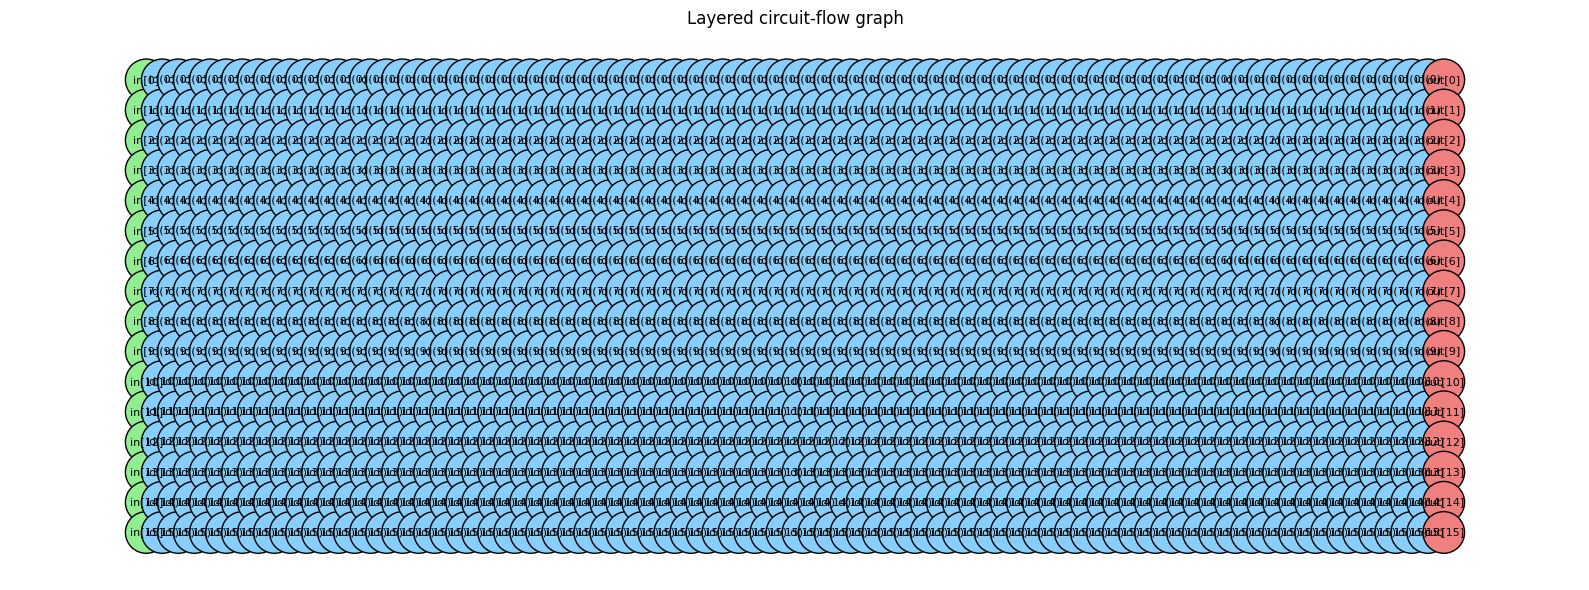

In [94]:
spec = make_identity_spec(n_qubits=16, n_layers=80)
qasm = to_qasm(spec, gates=spec.gates)

data, gate_features = qasm_to_pyg_graph(
    qasm,
    family="clifford",
    global_feature_variant="binned",
)

visualize_qasm_graph_layered(qasm, data)